# Mate-in-<3 Linear Probe

Train a linear probe on Lc0 residual-stream activations to detect whether the side-to-move has a forced mate in fewer than 3 moves (i.e. mate-in-1 or mate-in-2).

**Pipeline**
1. Build a labeled dataset from `data/interesting_puzzles.pkl` using Lichess `Themes` (`mateIn1` / `mateIn2` = positive).
2. For each FEN, run a forward pass through `Lc0Model` and capture `post_mlp.{L}` activations at every layer `L \in [0, 14]` — shape `[64, 768]` per position.
3. Mean-pool across the 64 squares to get a 768-d feature vector per position.
4. Fit a logistic regression probe per layer; report ROC-AUC and accuracy vs. layer depth.

## Setup

In [8]:
import os
import sys
import pickle

parent_dir = os.path.abspath('..')
leela_pytorch_impl_dir = os.path.join(parent_dir, 'leela_pytorch_impl')
for p in (parent_dir, leela_pytorch_impl_dir):
    if p not in sys.path:
        sys.path.append(p)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

from model import Lc0Model
from leela_board import LeelaBoard

In [9]:
ONNX_MODEL_NAME = 'lc0-original.onnx'
lc0 = Lc0Model(onnx_model_path=os.path.join(leela_pytorch_impl_dir, ONNX_MODEL_NAME))
N_LAYERS = lc0.N_LAYERS  # 15
D_MODEL = lc0.D_MODEL    # 768
print(f'N_LAYERS={N_LAYERS}, D_MODEL={D_MODEL}, device={lc0.device}')

Using device: cpu
N_LAYERS=15, D_MODEL=768, device=cpu


## Build dataset

- Positives: puzzles tagged `mateIn1` or `mateIn2` in `Themes`.
- Negatives: puzzles tagged `mateIn4`+ or non-mate themes (we exclude `mateIn3` to keep a clean margin between classes).
- We balance class counts to avoid a baseline that's just "predict the majority class."

In [10]:
PUZZLE_PATH = os.path.join(parent_dir, 'data', 'interesting_puzzles.pkl')
df = pickle.load(open(PUZZLE_PATH, 'rb'))
print(f'Loaded {len(df)} puzzles')
df['Themes'].head(3).tolist()

Loaded 22517 puzzles


['advancedPawn attraction mate mateIn2 middlegame promotion short',
 'attraction crushing endgame fork long sacrifice',
 'attraction crushing endgame exposedKing fork long sacrifice']

In [11]:
themes = df['Themes'].fillna('')
is_mate_lt3 = themes.str.contains(r'\bmateIn[12]\b', regex=True)
is_mate_ge3 = themes.str.contains(r'\bmateIn[3-9]\b', regex=True) | themes.str.contains(r'\bmateIn\d{2,}\b', regex=True)
is_any_mate = themes.str.contains(r'\bmate\b', regex=True) | themes.str.contains(r'\bmateIn\d+\b', regex=True)

pos = df[is_mate_lt3].copy()
pos['label'] = 1

# Negatives = non-mate puzzles (positions where there is no quick forced mate).
neg_mask = ~is_any_mate
neg = df[neg_mask].copy()
neg['label'] = 0

# Balance classes.
N_PER_CLASS = min(len(pos), len(neg), 1500)
rng = np.random.default_rng(0)
pos = pos.sample(n=N_PER_CLASS, random_state=0)
neg = neg.sample(n=N_PER_CLASS, random_state=0)

data = pd.concat([pos, neg]).sample(frac=1, random_state=0).reset_index(drop=True)
print(f'positives={len(pos)}, negatives={len(neg)}, total={len(data)}')

positives=1500, negatives=1500, total=3000


## Capture activations

We hook `post_mlp.0` ... `post_mlp.14` — the residual stream after each encoder block's MLP, shape `[batch, 64, 768]`. We process in chunks to stay within memory and mean-pool over the 64 squares before stashing, so we only keep `[N, 768]` per layer.

Activations are computed under `torch.no_grad()` (the model already disables grads, but we belt-and-suspender it).

In [12]:
LAYER_NAMES = [f'post_mlp.{L}' for L in range(N_LAYERS)]
BATCH_SIZE = 16  # bump up if you have GPU memory

fens = data['FEN'].tolist()
labels = data['label'].to_numpy()
N = len(fens)

# Preallocate one [N, 768] matrix per layer.
feat = {name: np.zeros((N, D_MODEL), dtype=np.float32) for name in LAYER_NAMES}

for start in range(0, N, BATCH_SIZE):
    end = min(start + BATCH_SIZE, N)
    boards = [LeelaBoard.from_fen(f) for f in fens[start:end]]
    inputs = lc0.make_inputs(boards)
    with torch.no_grad(), lc0.capturing(module_names=LAYER_NAMES) as acts:
        lc0(inputs)
        for name in LAYER_NAMES:
            a = acts[name]  # [b, 64, 768]
            pooled = a.mean(dim=1).cpu().numpy()  # mean over squares -> [b, 768]
            feat[name][start:end] = pooled
    if (start // BATCH_SIZE) % 10 == 0:
        print(f'  {end}/{N}')
print('done')

/home/aadim/projects/acm_chess_interp/chess-interp/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  x = x[pos_axes_slices]


  16/3000
  176/3000
  336/3000
  496/3000
  656/3000
  816/3000
  976/3000
  1136/3000
  1296/3000
  1456/3000
  1616/3000
  1776/3000
  1936/3000
  2096/3000
  2256/3000
  2416/3000
  2576/3000
  2736/3000
  2896/3000
done


## Train probes (one per layer)

Logistic regression with L2 on the mean-pooled 768-d features. Same train/test split across layers so the AUC curve is directly comparable.

In [13]:
idx_train, idx_test = train_test_split(np.arange(N), test_size=0.25, random_state=0, stratify=labels)
y_train, y_test = labels[idx_train], labels[idx_test]

results = []
for L, name in enumerate(LAYER_NAMES):
    X = feat[name]
    clf = LogisticRegression(C=1.0, max_iter=2000, n_jobs=-1)
    clf.fit(X[idx_train], y_train)
    prob = clf.predict_proba(X[idx_test])[:, 1]
    pred = (prob >= 0.5).astype(int)
    auc = roc_auc_score(y_test, prob)
    acc = accuracy_score(y_test, pred)
    results.append({'layer': L, 'auc': auc, 'acc': acc})
    print(f'layer {L:2d}  AUC={auc:.3f}  acc={acc:.3f}')

res_df = pd.DataFrame(results)
res_df

/home/aadim/projects/acm_chess_interp/chess-interp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


layer  0  AUC=0.752  acc=0.672


/home/aadim/projects/acm_chess_interp/chess-interp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


layer  1  AUC=0.829  acc=0.755


/home/aadim/projects/acm_chess_interp/chess-interp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

/home/aadim/projects/acm_chess_interp/chess-interp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


layer 13  AUC=0.927  acc=0.853


/home/aadim/projects/acm_chess_interp/chess-interp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


layer 14  AUC=0.863  acc=0.789


,layer,auc,acc
0,0,0.751673,0.672000
1,1,0.829312,0.754667
2,2,0.851996,0.782667
3,3,0.865721,0.782667
4,4,0.878450,0.808000
5,5,0.884060,0.812000
6,6,0.899961,0.837333
7,7,0.907058,0.841333
8,8,0.909739,0.858667
9,9,0.916843,0.857333


## Plot AUC vs. layer

Look for the layer where the probe's AUC starts rising — that's roughly where the model first represents the "mate-in-<3" concept linearly. A rise that saturates in mid-to-late layers is the typical pattern.

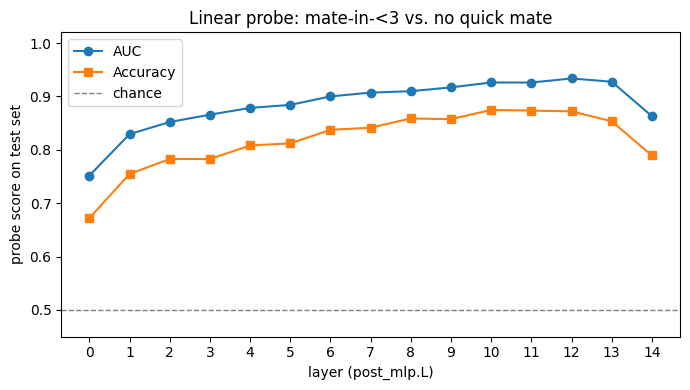

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res_df['layer'], res_df['auc'], marker='o', label='AUC')
ax.plot(res_df['layer'], res_df['acc'], marker='s', label='Accuracy')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance')
ax.set_xlabel('layer (post_mlp.L)')
ax.set_ylabel('probe score on test set')
ax.set_title('Linear probe: mate-in-<3 vs. no quick mate')
ax.set_xticks(range(N_LAYERS))
ax.set_ylim(0.45, 1.02)
ax.legend()
fig.tight_layout()
plt.show()

## Next steps

- **Per-square probe**: drop the mean-pool, flatten to `[N, 64*768]`, and probe — useful to localize *which square* carries the mate signal (e.g., is it the king square, the mating-piece square?).
- **Probe other streams**: try `post_attention.{L}` (residual after attn, before MLP) and `attention_output.{L}` / `mlp_output.{L}` to see whether mate detection comes from attention or MLP.
- **Stockfish ground truth**: the Lichess `Themes` labels are noisy (e.g., a `mateIn2` puzzle is tagged on the *attacker's* move but the FEN may be the defender's move). Re-labeling FENs with `stockfish.analyse(..., depth=15).score.mate()` is cleaner.
- **Cross-validate** rather than a single split, and sweep the L2 `C` parameter.